===== FIRST 5 ROWS =====
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horse

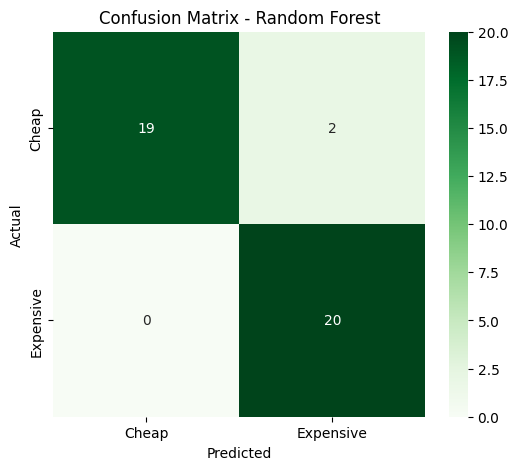


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

       Cheap       1.00      0.90      0.95        21
   Expensive       0.91      1.00      0.95        20

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.96      0.95      0.95        41



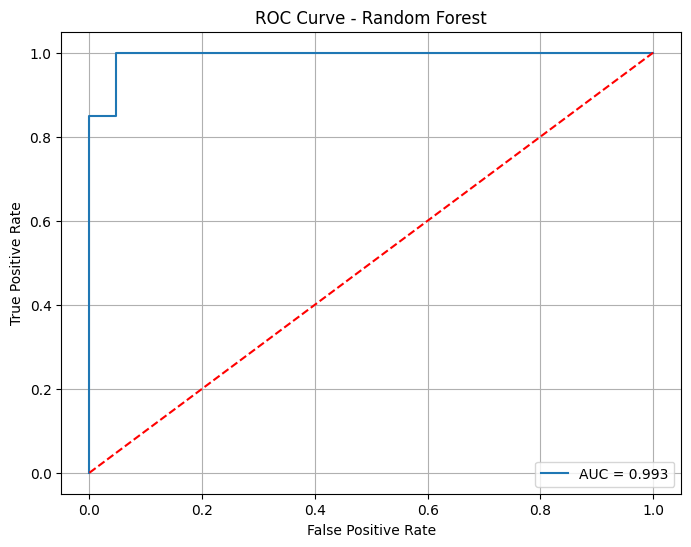


===== FEATURE IMPORTANCE =====
      Feature  Importance
2  curbweight    0.324135
1  horsepower    0.150128
5    carwidth    0.146292
7  highwaympg    0.136816
6     citympg    0.069246
0  enginesize    0.065003
4   carlength    0.057849
3   wheelbase    0.050532


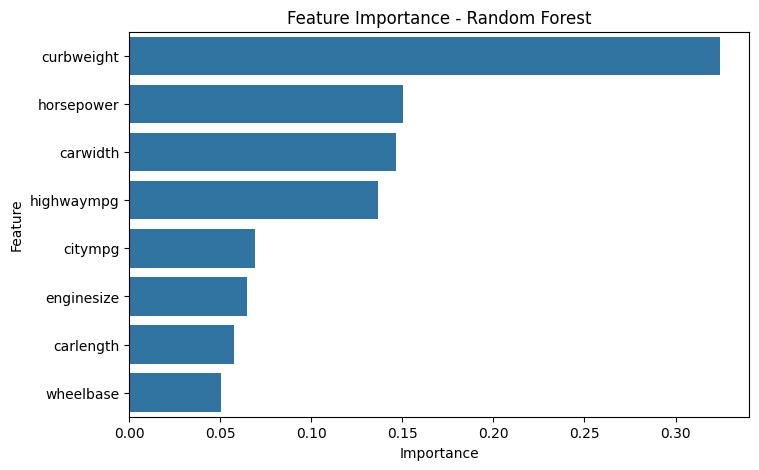


===== ACTUAL VS PREDICTED =====
   Actual  Predicted  Probability_Expensive
0       1          1                  1.000
1       1          1                  0.823
2       1          1                  0.988
3       0          0                  0.438
4       0          0                  0.149
5       0          0                  0.000
6       0          0                  0.000
7       1          1                  1.000
8       0          0                  0.003
9       0          0                  0.117

===== NEW CAR PREDICTION =====
Prediction : CHEAP CAR
Probability of being expensive: 36.83%


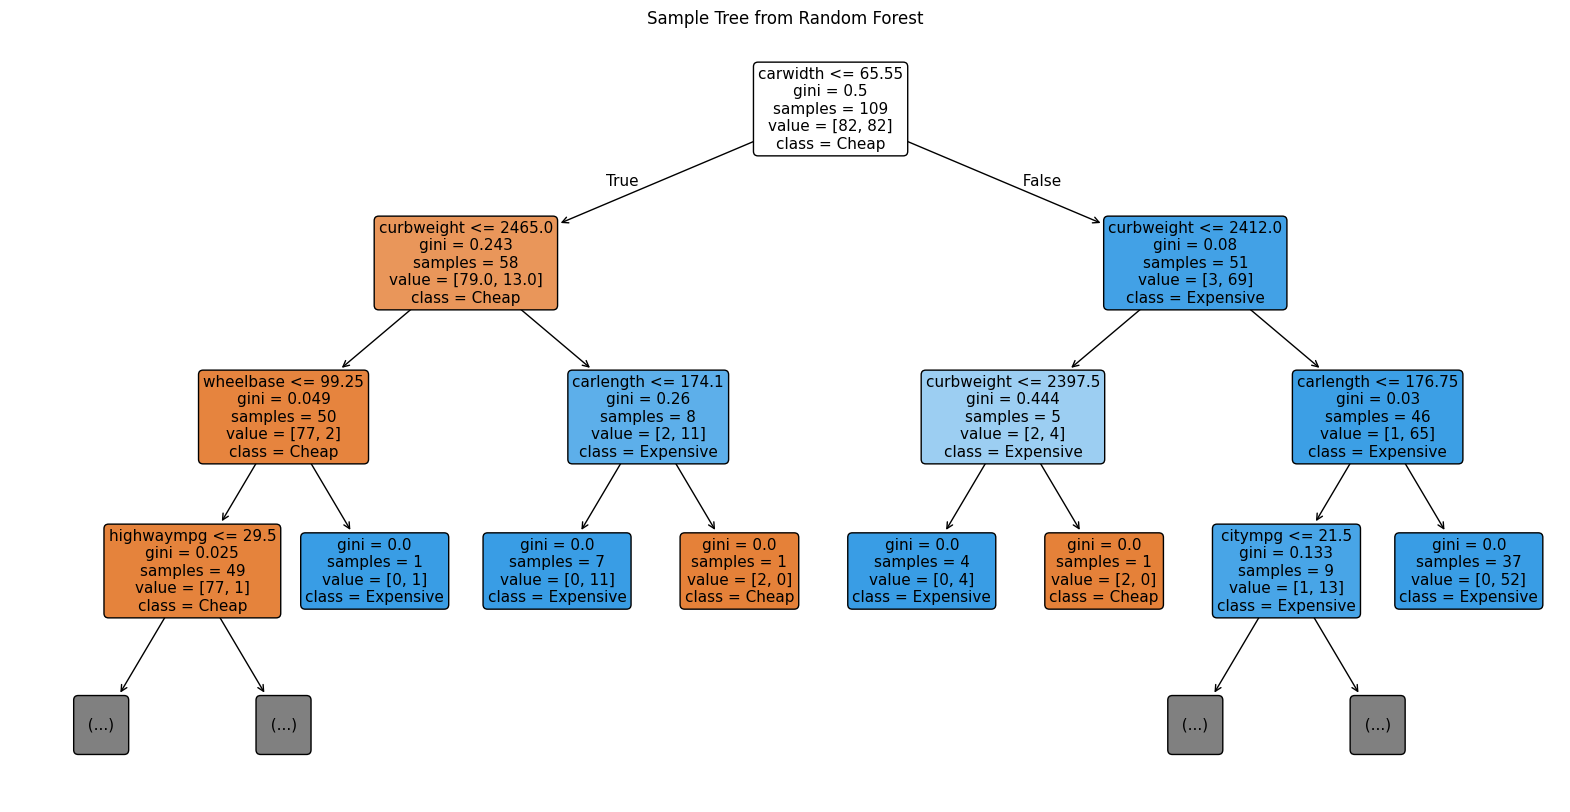

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv('/content/CarPrice_Assignment.csv')

print("===== FIRST 5 ROWS =====")
print(df.head())


median_price = df['price'].median()

df['price_class'] = np.where(df['price'] > median_price, 1, 0)

print("\nMedian Price:", median_price)

print("\n===== TARGET DISTRIBUTION =====")
print(df['price_class'].value_counts())


features = [
    'enginesize',
    'horsepower',
    'curbweight',
    'wheelbase',
    'carlength',
    'carwidth',
    'citympg',
    'highwaympg'
]

X = df[features]
y = df['price_class']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== TRAIN TEST SHAPES =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("\n===== MODEL TRAINED SUCCESSFULLY =====")


y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== MODEL EVALUATION =====")
print(f"Accuracy Score : {accuracy:.4f}")
print(f"ROC-AUC Score  : {auc:.4f}")


cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cheap', 'Expensive'],
            yticklabels=['Cheap', 'Expensive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred,
                            target_names=['Cheap', 'Expensive']))


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()


importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance - Random Forest')
plt.show()


results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_Expensive': np.round(y_prob, 3)
})

print("\n===== ACTUAL VS PREDICTED =====")
print(results.head(10))


new_car = pd.DataFrame({
    'enginesize': [130],
    'horsepower': [111],
    'curbweight': [2500],
    'wheelbase': [95],
    'carlength': [170],
    'carwidth': [65],
    'citympg': [25],
    'highwaympg': [32]
})

prediction = model.predict(new_car)[0]

probability = model.predict_proba(new_car)[0][1]

print("\n===== NEW CAR PREDICTION =====")

if prediction == 1:
    print("Prediction : EXPENSIVE CAR")
else:
    print("Prediction : CHEAP CAR")

print(f"Probability of being expensive: {probability:.2%}")


from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model.estimators_[0],
    feature_names=features,
    class_names=['Cheap', 'Expensive'],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title('Sample Tree from Random Forest')
plt.show()